## Import and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from collections import Counter
from scipy import stats

import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 11

In [2]:
df = pd.read_csv('../data/student_dropout_dataset.csv')

## Data Understandning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 18 columns):
 #   Column                                                                                                                                                                                                                                        Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                                        --------------  -----
 0   Timestamp                                                                                                                                                                                                                                     556 non-null    str  
 1   1. Name of Student (Ex. NUON CHANVATHANA)
ឈ្មោះសិស្ស (ឧទាហរណ៍៖​ នួន ច័ន្ទវឌ្ឍនា)                          

In [4]:
df.shape

(556, 18)

In [5]:
df.describe(include='all').T

,count,unique,top,freq
Timestamp,556,553,3/21/2026 12:02:08,2
1. Name of Student (Ex. NUON CHANVATHANA)\nឈ្មោះសិស្ស (ឧទាហរណ៍៖​ នួន ច័ន្ទវឌ្ឍនា),554,493,ឈឿន តុលា,4
name,532,476,Pich Chan Rasmey,4
2. Gender\nភេទ,556,5,Female (ស្រី),341
3. Age___Years old.(In Number)\nអាយុ (ឧទាហរណ៍៖ 16),556,28,17,116
4. From the Province (Ex. Kampot)\nមកពីខេត្ត (ឧទាហរណ៍៖​ កំពត),556,13,កំពង់ចាម,260
5. Level of Study (Ex. Grade 8)\nសិក្សានៅថ្នាក់ទី____(ឧទាហរណ៍៖​​ 8),556,35,12,143
6. Who did you live with during lower secondary school?\nតើអ្នករស់នៅជាមួយអ្នកណាក្នុងកំឡុងពេលសិក្សានៅកម្រិតអនុវិទ្យាល័យ ?,556,12,Both parents (ឪពុកនិងម្ដាយ),375
7. How was your home from school?\nតើផ្ទះរបស់អ្នកមានចម្ងាយប៉ុន្មានពីសាលារៀន?,556,3,between 1km-5km (ចន្លោះ1គីឡូម៉ែត្រ ទៅ5គីឡូម៉ែត្រ),255
8. What means of transportation did you usually use to get to school?\nតើអ្នកប្រើប្រាស់មធ្យោបាយធ្វើដំណើរអ្វីដើម្បីទៅសាលារៀន?,556,4,Motorbike (ម៉ូតូ),402


## Data Preproccessing

In [6]:
df.drop(columns=[
    'Timestamp', 
    '1. Name of Student (Ex. NUON CHANVATHANA)\nឈ្មោះសិស្ស (ឧទាហរណ៍៖​ នួន ច័ន្ទវឌ្ឍនា)',
    ], 
    inplace=True)

In [7]:
df.columns

Index(['name', '2. Gender\nភេទ ',
       '3. Age___Years old.(In Number)\nអាយុ (ឧទាហរណ៍៖ 16)',
       '4. From the Province (Ex. Kampot)\nមកពីខេត្ត (ឧទាហរណ៍៖​ កំពត)',
       '5. Level of Study (Ex. Grade 8)\nសិក្សានៅថ្នាក់ទី____(ឧទាហរណ៍៖​​ 8)',
       '6. Who did you live with during lower secondary school?\nតើអ្នករស់នៅជាមួយអ្នកណាក្នុងកំឡុងពេលសិក្សានៅកម្រិតអនុវិទ្យាល័យ ?',
       '7. How was your home from school?\nតើផ្ទះរបស់អ្នកមានចម្ងាយប៉ុន្មានពីសាលារៀន?',
       '8. What means of transportation did you usually use to get to school?\nតើអ្នកប្រើប្រាស់មធ្យោបាយធ្វើដំណើរអ្វីដើម្បីទៅសាលារៀន?',
       '9. How many days did you attend school per week?\nតើអ្នកចូលរៀនប៉ុន្មានថ្ងៃក្នុងមួយសប្តាហ៍?',
       '10. How often did you miss school?\nតើអ្នកឈប់រៀនញឹកញាប់ប៉ុណ្ណាក្នុងមួយសប្តាហ៍?',
       '12. What is the highest education level of your parents?\nតើឪពុកម្តាយរបស់អ្នកមានការសិក្សាអប់រំកម្រិតប៉ុន្នាន?',
       '13. What is the family's interest rate?\nតើគ្រួសាររបស់អ្នកមានកម្រិតជីវភាពយ៉ាងដូចម្ដេ

In [8]:
# Rename columns
df.columns = [
    "student_name",
    "gender",
    "age",
    "province",
    "study_level",
    "living_with",
    "distance",
    "transport",
    "attendance",
    "absence",
    "parental_education",
    "family_income",
    "work_support",
    "monthly_average",
    "thought_dropout",
    "external_support",
]

df.columns

Index(['student_name', 'gender', 'age', 'province', 'study_level',
       'living_with', 'distance', 'transport', 'attendance', 'absence',
       'parental_education', 'family_income', 'work_support',
       'monthly_average', 'thought_dropout', 'external_support'],
      dtype='str')

In [9]:
def remove_khmer_text(text):
    """Remove Khmer text inside parentheses"""
    if pd.isna(text) or text == "":
        return text
    
    text = str(text)
    # Regex: removes anything in () that contains Khmer characters (U+1780-U+17FF)
    cleaned = re.sub(r'\s*\([^)]*[\u1780-\u17FF]+[^)]*\)', '', text)
    return cleaned.strip()

In [10]:
df_te = df.copy()

for col in df_te.columns:
    df_te[col] = df_te[col].apply(remove_khmer_text)
    
df_te.head()

,student_name,gender,age,province,study_level,living_with,distance,transport,attendance,absence,parental_education,family_income,work_support,monthly_average,thought_dropout,external_support
0,NUON CHANVATHANA,Male,21,កំពត,8,Both parents,Less than 1km,Motorbike,5 - 6 days,Never,High School,Medium,No,More than 40.00,No,No
1,Phiroun Sovanneary Roth,Female,18,បាត់ដំបង,College,Both parents,between 1km-5km,Motorbike,5 - 6 days,Never,High School,Medium,No,Between 25.00 to 40.00,No,No
2,no,Male,18,តាកែវ,12,Both parents,between 1km-5km,Motorbike,5 - 6 days,Sometimes,High School,Medium,No,Between 25.00 to 40.00,Yes,No
3,Thuen Ratana,Male,17,កំពង់ចាម,12,Both parents,between 1km-5km,Motorbike,5 - 6 days,Never,Primary school,Medium,No,Between 25.00 to 40.00,No,No
4,Kan Sok Mean,Female,16,កំពត,12,Both parents,Less than 1km,Motorbike,5 - 6 days,Never,Primary school,Medium,No,More than 40.00,No,No


In [11]:
# move thought_dropout to the end
cols = [col for col in df_te.columns if col != 'thought_dropout'] + ['thought_dropout']
df_te = df_te[cols]
df_te.head()

,student_name,gender,age,province,study_level,living_with,distance,transport,attendance,absence,parental_education,family_income,work_support,monthly_average,external_support,thought_dropout
0,NUON CHANVATHANA,Male,21,កំពត,8,Both parents,Less than 1km,Motorbike,5 - 6 days,Never,High School,Medium,No,More than 40.00,No,No
1,Phiroun Sovanneary Roth,Female,18,បាត់ដំបង,College,Both parents,between 1km-5km,Motorbike,5 - 6 days,Never,High School,Medium,No,Between 25.00 to 40.00,No,No
2,no,Male,18,តាកែវ,12,Both parents,between 1km-5km,Motorbike,5 - 6 days,Sometimes,High School,Medium,No,Between 25.00 to 40.00,No,Yes
3,Thuen Ratana,Male,17,កំពង់ចាម,12,Both parents,between 1km-5km,Motorbike,5 - 6 days,Never,Primary school,Medium,No,Between 25.00 to 40.00,No,No
4,Kan Sok Mean,Female,16,កំពត,12,Both parents,Less than 1km,Motorbike,5 - 6 days,Never,Primary school,Medium,No,More than 40.00,No,No


In [12]:
df_te['age'].unique()

<ArrowStringArray>
[             '21',              '18',              '17',              '16',
              '15',              '19',              '20',              '27',
         'អាយុ 17',         '15ឆ្នាំ',              '14', 'Age17 Years old',
        '១៦ ឆ្នាំ',         '16ឆ្នាំ',              '32',              '26',
              '23',     'អាយុ16ឆ្នាំ',   'Iam13Yearsold',          'អាយុ15',
              '12',              '13',          'អាយុ13',         '14ឆ្នាំ',
        '15 ឆ្នាំ',         '13ឆ្នាំ',         '12ឆ្នាំ',            '1000']
Length: 28, dtype: str

In [13]:
df_te['age'] = df_te['age'].str.extract('(\d+)').astype(int)
df_te['age'].describe().T

count     556.000000
mean       17.908273
std        41.788190
min        12.000000
25%        15.000000
50%        16.000000
75%        17.000000
max      1000.000000
Name: age, dtype: float64

In [14]:
# remove unsual age values (e.g., 0, 100+)
df_te = df_te[(df_te['age'] >= 5) & (df_te['age'] <= 30)]

In [15]:
df_te['province'].unique()

<ArrowStringArray>
[        'កំពត',     'បាត់ដំបង',        'តាកែវ',     'កំពង់ចាម',
      'ភ្នំពេញ',   'ត្បូងឃ្មុំ',       'សៀមរាប',       'កណ្តាល',
      'ព្រៃវែង',    'កំពង់ស្ពឺ',     'ស្វាយរៀង', 'បន្ទាយមានជ័យ',
          'កែប']
Length: 13, dtype: str

In [16]:
# provine mapping

province_mapping = {
    'កំពត': 'Kampot',
    'បាត់ដំបង': 'Battambang',
    'តាកែវ': 'Takeo',
    'កំពង់ចាម': 'Kampong Cham',
    'ភ្នំពេញ': 'Phnom Penh', 
    'ត្បូងឃ្មុំ': 'Tbong Khmum',
    'សៀមរាប': 'Siemreap', 
    'កណ្តាល': 'Kandal', 
    'ព្រៃវែង': 'Prey Veng', 
    'កំពង់ស្ពឺ': 'Kampong Speu', 
    'ស្វាយរៀង': 'Svay Rieng', 
    'កំពង់ធំ': 'Kampong Thom', 
    'បន្ទាយមានជ័យ': 'Banteay Meanchey', 
    'កែប': 'Kep'
}

df_te['province'] = df_te['province'].map(province_mapping).fillna(df_te['province'])

In [17]:
df_te['study_level'].unique()

<ArrowStringArray>
[                              '8',                         'College',
                              '12',                               '9',
                           'Year1',                          'Year 1',
                           'Year3',                          'Year 3',
                              '10',                   'Undergraduate',
          '3rd year undergraduate',                          'Year-3',
                        '3rd year',                       'Gratuated',
                      'University',                              '11',
                     'Second year',                    'Uni 1st year',
                        'ឆ្នាំទី1',                 'Bachelor degree',
 'និស្សិតឯកទេសនីតិសាធារណៈឆ្នាំទី3',                    'មហាវិទ្យាល័យ',
                               '7',                        'ឆ្នាំទី3',
                        'ឆ្នាំទី២',                          'Year 2',
                              '16',                       

In [18]:

data = ['8', 'College', '12', '9', 'Year1', 'Year 1', 'Year3', 'Year 3',
        '10', 'Undergraduate', '3rd year undergraduate', 'Year-3',
        '3rd year', 'Gratuated', 'University', '11', 'Second year',
        'Uni 1st year', 'ឆ្នាំទី1', 'Bachelor degree',
        'និស្សិតឯកទេសនីតិសាធារណៈឆ្នាំទី3', 'មហាវិទ្យាល័យ', '7', 'ឆ្នាំទី3',
        'ឆ្នាំទី២', 'Year 2', '16', '13', '15', 'សាកលវិទ្យាល័យ', '14',
        'Master', '3 year']

tedf = pd.DataFrame({'raw_input': data})

def clean_study_level(val):
    val_str = str(val).lower().strip()
    
    if any(x in val_str for x in ['ឆ្នាំទី1', 'ឆ្នាំទី១', 'year1', 'year 1', '1st year']):
        return 'University Year 1'
        
    if any(x in val_str for x in ['ឆ្នាំទី2', 'ឆ្នាំទី២', 'year2', 'year 2', 'second year']):
        return 'University Year 2'
        
    if any(x in val_str for x in ['ឆ្នាំទី3', 'ឆ្នាំទី៣', 'year3', 'year 3', '3rd year', '3 year', 'year-3']):
        return 'University Year 3'
        
    if any(x in val_str for x in ['gratuated', 'master']):
        return 'Graduated / Postgraduate'
        
    if any(x in val_str for x in ['college', 'undergraduate', 'university', 'bachelor', 'មហាវិទ្យាល័យ', 'សាកលវិទ្យាល័យ']):
        return 'University (Unspecified)'
        
    if val_str.isdigit():
        grade_num = int(val_str)
        if 1 <= grade_num <= 12:
            return f'Grade {grade_num}'

    return 'Unknown' # Catch-all for messy dat

df_te['study_level'] = tedf['raw_input'].apply(clean_study_level)

df_te.head()

,student_name,gender,age,province,study_level,living_with,distance,transport,attendance,absence,parental_education,family_income,work_support,monthly_average,external_support,thought_dropout
0,NUON CHANVATHANA,Male,21,Kampot,Grade 8,Both parents,Less than 1km,Motorbike,5 - 6 days,Never,High School,Medium,No,More than 40.00,No,No
1,Phiroun Sovanneary Roth,Female,18,Battambang,University (Unspecified),Both parents,between 1km-5km,Motorbike,5 - 6 days,Never,High School,Medium,No,Between 25.00 to 40.00,No,No
2,no,Male,18,Takeo,Grade 12,Both parents,between 1km-5km,Motorbike,5 - 6 days,Sometimes,High School,Medium,No,Between 25.00 to 40.00,No,Yes
3,Thuen Ratana,Male,17,Kampong Cham,Grade 9,Both parents,between 1km-5km,Motorbike,5 - 6 days,Never,Primary school,Medium,No,Between 25.00 to 40.00,No,No
4,Kan Sok Mean,Female,16,Kampot,University Year 1,Both parents,Less than 1km,Motorbike,5 - 6 days,Never,Primary school,Medium,No,More than 40.00,No,No


In [19]:
cols = df_te.columns

for col in cols:
    print(f"Unique values in '{col}': {df_te[col].unique()}\n")

Unique values in 'student_name': <ArrowStringArray>
[       'NUON CHANVATHANA', 'Phiroun Sovanneary Roth',
                      'no',            'Thuen Ratana',
            'Kan Sok Mean',              'Phet Narin',
            'Ri Sovannita',         'KIM PUTDARARITH',
             'Sohmat Azim',       'HORN Samborokisin',
 ...
          'Nethrithi Pong',               'Nha Thera',
            'Thuen Solita',      'Nim Chantara Rithy',
         'Kheng Sujeanita',                'Say Davy',
              'Live, earn',        'Sang Sovannaroth',
        'Nuon chanvathana',            'ly rithyvann']
Length: 476, dtype: str

Unique values in 'gender': <ArrowStringArray>
['Male', 'Female', 'ស្រី', 'Gay', 'ប្រុស']
Length: 5, dtype: str

Unique values in 'age': [21 18 17 16 15 19 20 27 14 26 23 13 12]

Unique values in 'province': <ArrowStringArray>
[          'Kampot',       'Battambang',            'Takeo',
     'Kampong Cham',       'Phnom Penh',      'Tbong Khmum',
         'Siemreap',

In [20]:
gender_map = {
    'ស្រី': 'Female',
    'ប្រុស': 'Male',
    'Male': 'Male',
    'Female': 'Female',
    'Gay': 'Other'
}
df_te['gender'] = df_te['gender'].map(gender_map)
df_te['gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

In [21]:
living_map = {
    'Both parents': 'Both parents',
    'One parent': 'One parent',
    'Guardians or relatives': 'Guardians/Relatives',
    'ម្តាយ': 'One parent',          # Mother
    'យាយ': 'Guardians/Relatives',   # Grandmother
    'ជីដូន': 'Guardians/Relatives',  # Grandmother
    'ជីដូនជីតា': 'Guardians/Relatives', # Grandparents
    'យាយតា': 'Guardians/Relatives',   # Grandparents
    'តា យាា': 'Guardians/Relatives',  # Grandparents (typo variation)
    'ឪពុក_លោកយាយ_លោកតា': 'Guardians/Relatives' # Father/Grandparents
}
df_te['living_with'] = df_te['living_with'].map(living_map)
df_te['living_with'].unique()

<ArrowStringArray>
['Both parents', 'One parent', 'Guardians/Relatives', nan]
Length: 4, dtype: str

In [22]:
parent_edu_map = {
    'No education': 'No education',
    'Primary school': 'Primary school',
    'Secondary School': 'Secondary school',
    'High School': 'High school',
    'Higher education': 'Higher education'
}
df_te['parental_education'] = df_te['parental_education'].map(parent_edu_map)

In [23]:
df_te.isna().sum()

student_name           23
gender                  0
age                     0
province                0
study_level           521
living_with             1
distance                0
transport               0
attendance              0
absence                 0
parental_education      0
family_income           0
work_support            0
monthly_average         0
external_support        0
thought_dropout         0
dtype: int64

In [24]:
atten_map = {
    '5 - 6 days': '5-6 days',
    '3 -4 days': '3-4 days',
    '0 - 2 days': '0-2 days',
}
df_te['attendance'] = df_te['attendance'].map(atten_map)

In [25]:
df_te['living_with'] = df_te['living_with'].fillna(df_te['living_with'].mode()[0])

## Exploratory Data Analysis (EDA)

### UNIVARIATE EDA

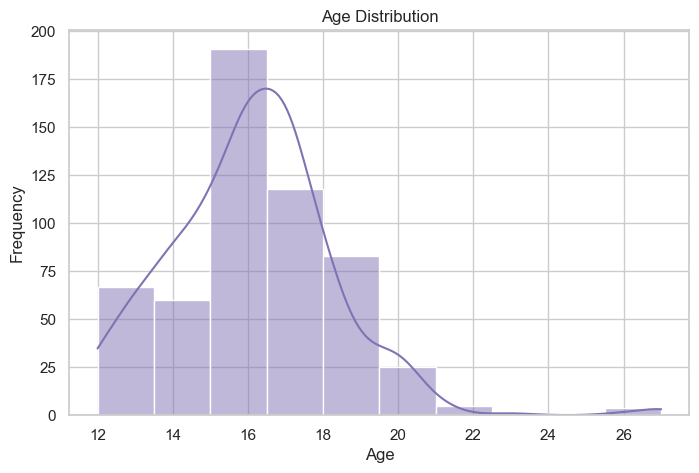

In [26]:
sns.histplot(df_te['age'], bins=10, kde=True, color=sns.color_palette('deep')[4])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

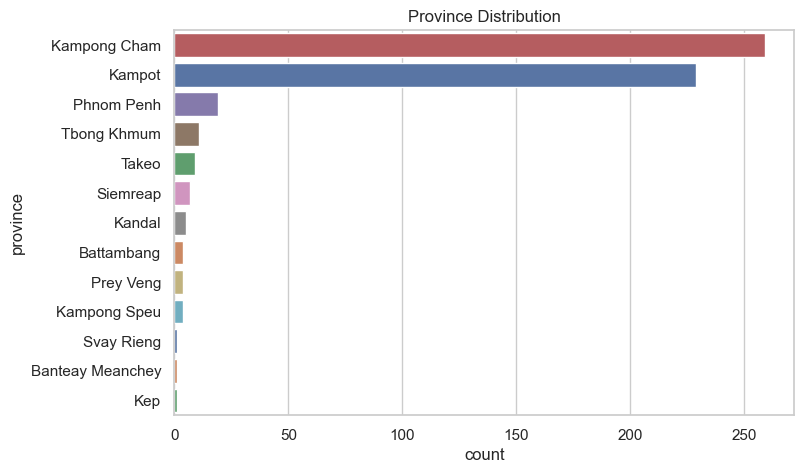

In [27]:
sns.countplot(
    data=df_te,
    y='province',
    order=df_te['province'].value_counts().index,
    hue='province',
    palette='deep'
)
plt.title("Province Distribution")
plt.show()

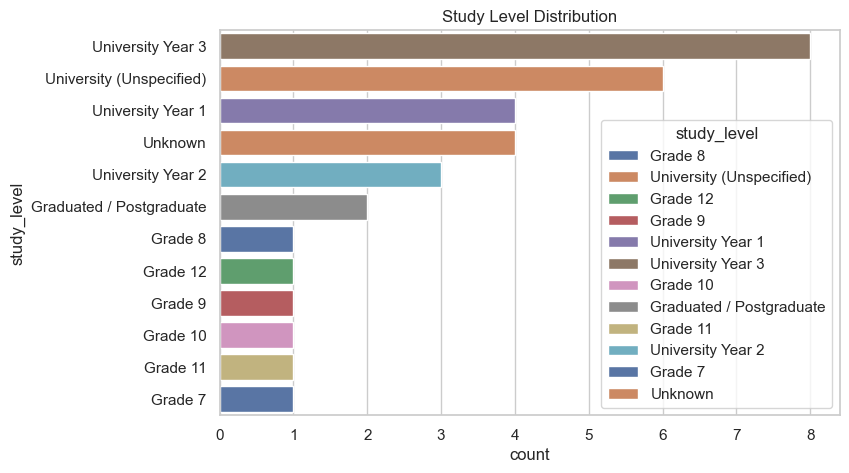

In [28]:
sns.countplot(
    data=df_te,
    y='study_level',
    order=df_te['study_level'].value_counts().index,
    hue='study_level',
    palette='deep'
)
plt.title("Study Level Distribution")
plt.show()

In [29]:
df_cleaned = df_te.copy()
cols_to_drop = ['student_name', 'province', 'age', 'study_level']
df_cleaned = df_cleaned.drop(columns=cols_to_drop, errors='ignore')
df_cleaned = df_cleaned.drop_duplicates()
df_cleaned.columns


Index(['gender', 'living_with', 'distance', 'transport', 'attendance',
       'absence', 'parental_education', 'family_income', 'work_support',
       'monthly_average', 'external_support', 'thought_dropout'],
      dtype='str')

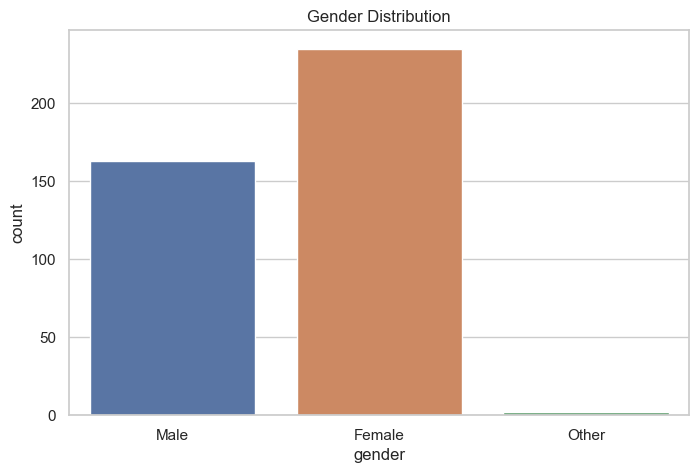

In [30]:
sns.countplot(data=df_cleaned, x='gender', hue='gender')
plt.title("Gender Distribution")
plt.show()

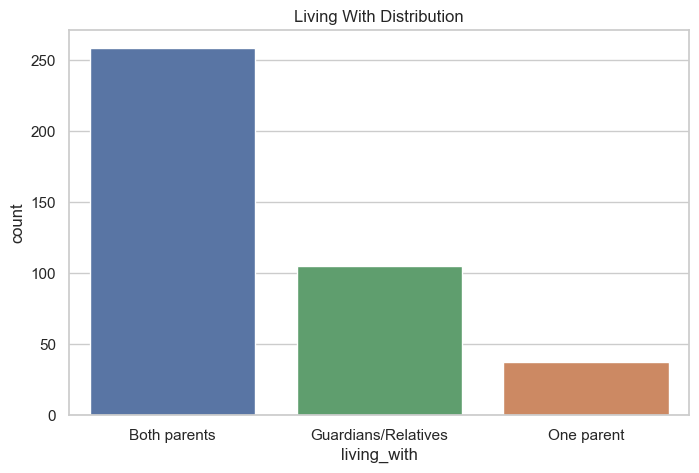

In [31]:
sns.countplot(
    data=df_cleaned, 
    x='living_with', 
    hue='living_with',
    order=df_cleaned['living_with'].value_counts().index
)
plt.title("Living With Distribution")
plt.show()

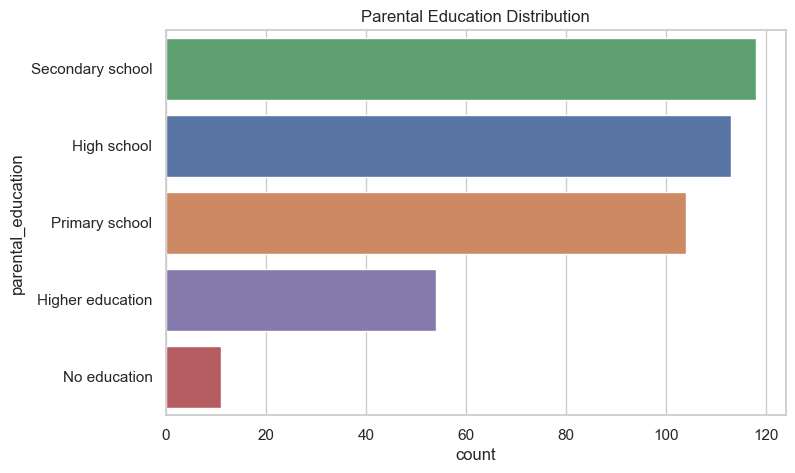

In [32]:
sns.countplot(
    data=df_cleaned,
    y='parental_education',
    order=df_cleaned['parental_education'].value_counts().index,
    hue='parental_education'
)   
plt.title("Parental Education Distribution")
plt.show()

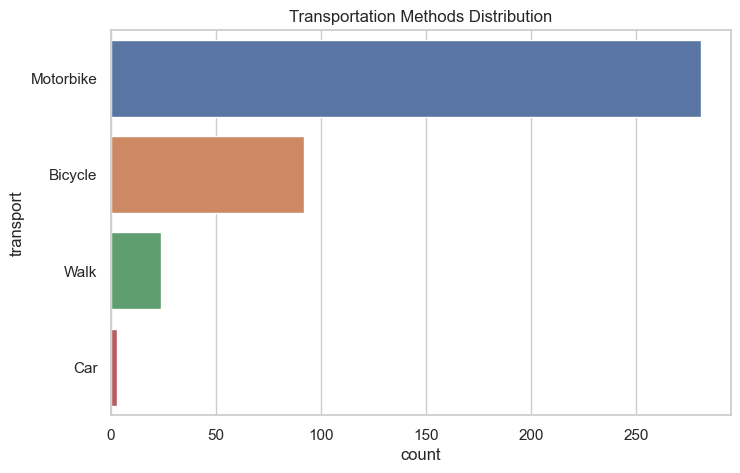

In [33]:
sns.countplot(
    data=df_cleaned,
    y='transport',
    order=df_cleaned['transport'].value_counts().index,
    hue='transport'
)
plt.title("Transportation Methods Distribution")
plt.show()

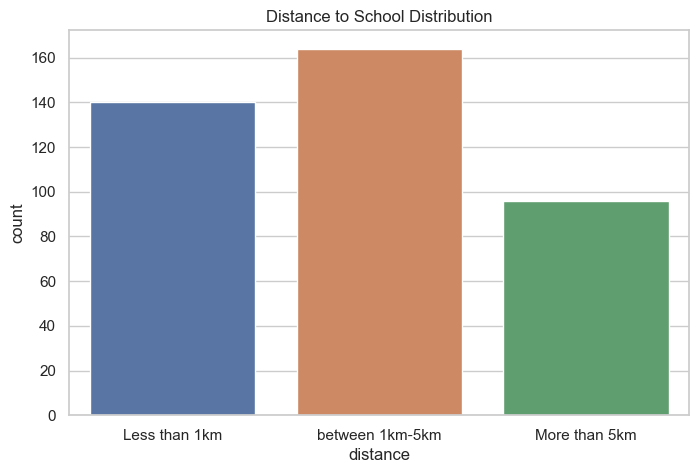

In [34]:
sns.countplot(
    data=df_cleaned,
    x='distance',
    hue='distance'
)
plt.title("Distance to School Distribution")
plt.show()

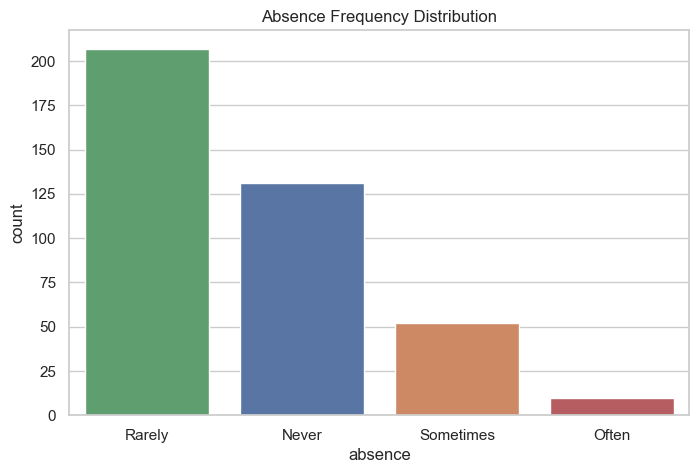

In [35]:
sns.countplot(
    data=df_cleaned,
    x='absence',
    order=df_cleaned['absence'].value_counts().index,
    hue='absence'
)
plt.title("Absence Frequency Distribution")
plt.show()

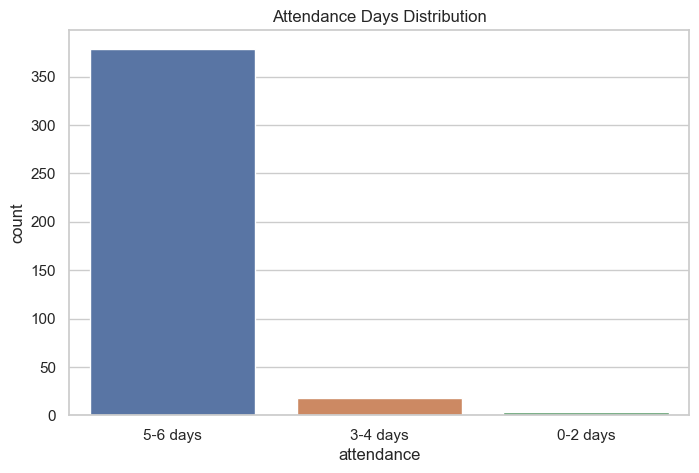

In [36]:
sns.countplot(
    data=df_cleaned,
    x='attendance',
    hue='attendance'
)
plt.title("Attendance Days Distribution")
plt.show()  

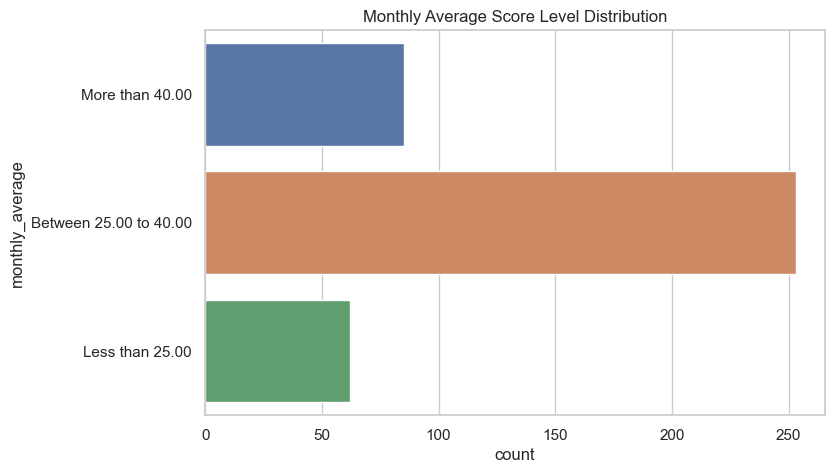

In [37]:
sns.countplot(
    data=df_cleaned,
    y='monthly_average',
    # order=df_cleaned['monthly_average_score_level'].value_counts().index,
    hue='monthly_average'
)
plt.title("Monthly Average Score Level Distribution")
plt.show()

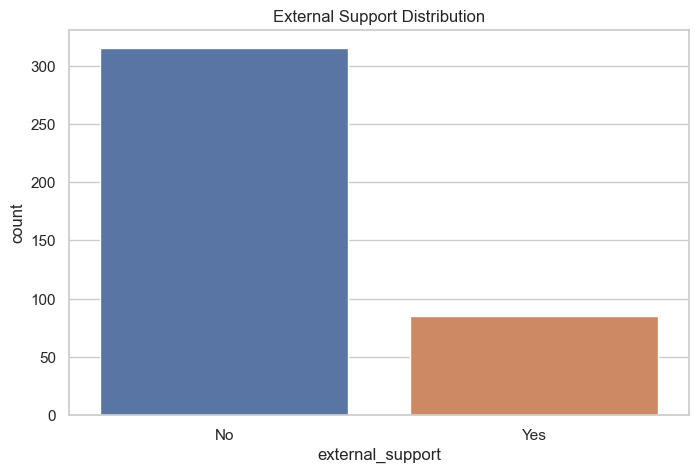

In [38]:
sns.countplot(
    data=df_cleaned,
    x='external_support',
    order=df_cleaned['external_support'].value_counts().index,
    hue='external_support'
)   
plt.title("External Support Distribution")
plt.show()

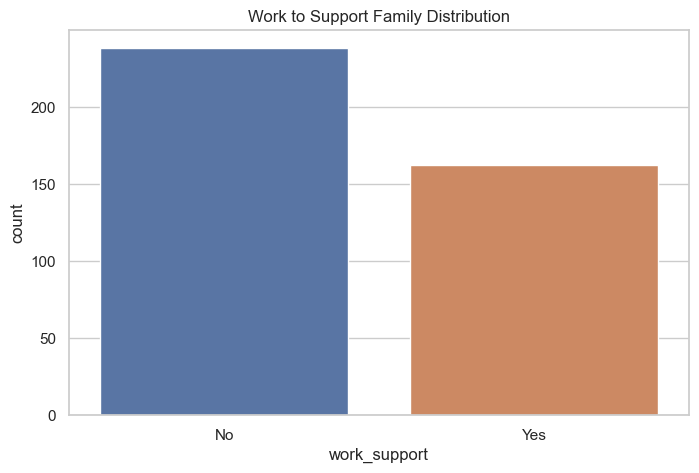

In [39]:
sns.countplot(
    data=df_cleaned,
    x='work_support',
    hue='work_support'
)
plt.title("Work to Support Family Distribution")    
plt.show()

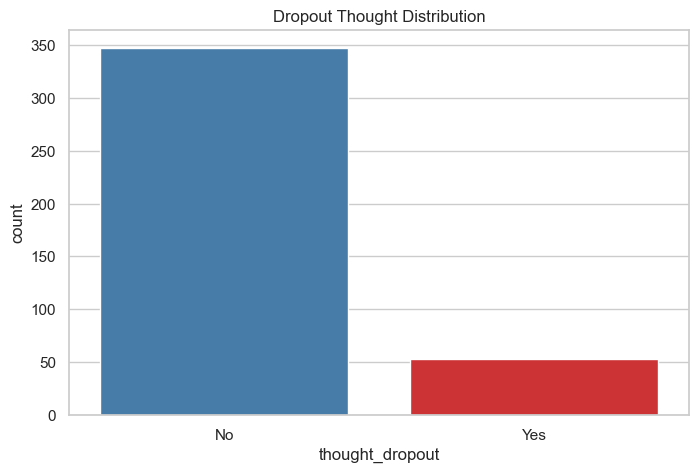

In [40]:
set1_colors = sns.color_palette("Set1")
yes_no_palette = {"Yes": set1_colors[0], "No": set1_colors[1]}
sns.countplot(data=df_cleaned, x='thought_dropout', hue='thought_dropout', palette=yes_no_palette)
plt.title("Dropout Thought Distribution")
plt.show()

### BIVARIATE EDA

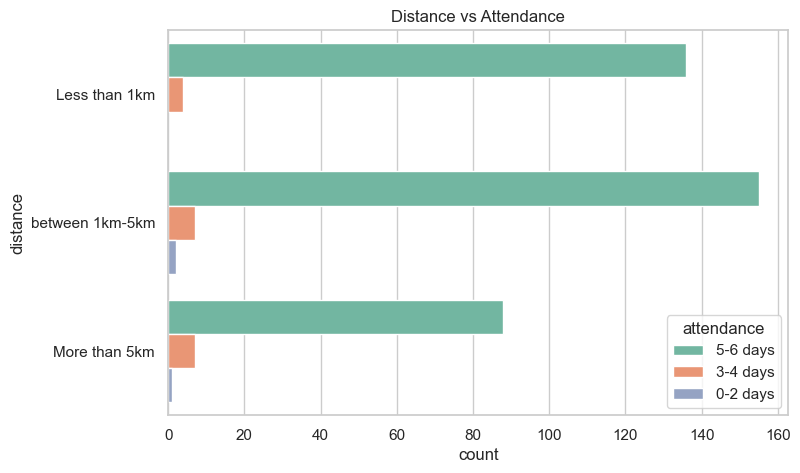

In [41]:
sns.countplot(
    data=df_cleaned,
    y='distance',
    hue='attendance',
    palette="Set2"
)

plt.title("Distance vs Attendance")
plt.show()

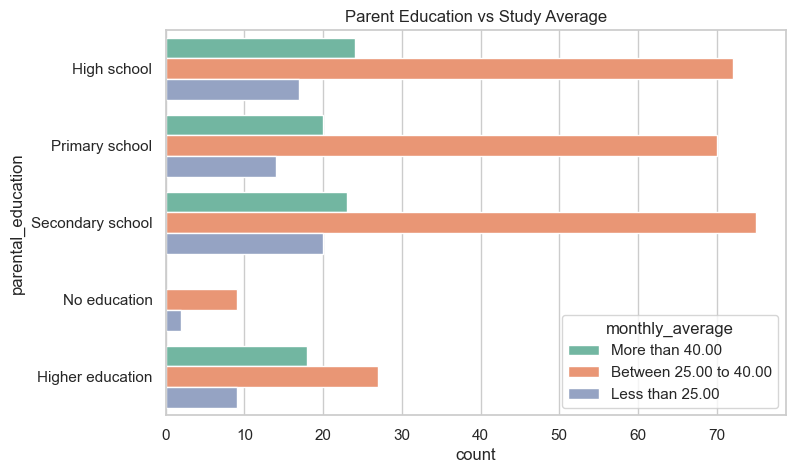

In [42]:
sns.countplot(
    data=df_cleaned,
    y='parental_education',
    hue='monthly_average',
    palette="Set2"
)
plt.title("Parent Education vs Study Average")
plt.show()

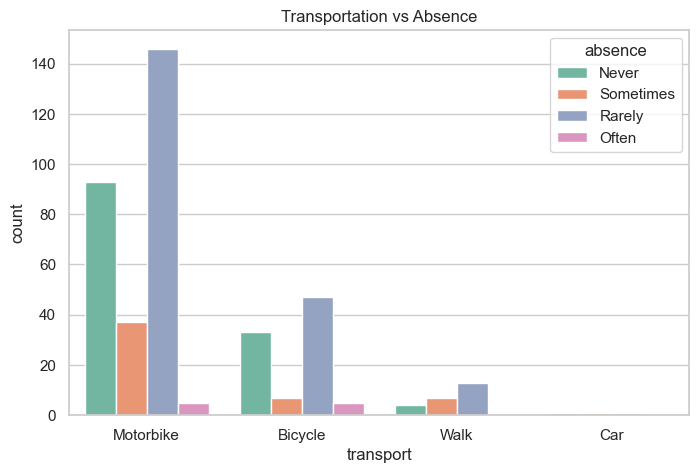

In [43]:
sns.countplot(
    data=df_cleaned,
    x='transport',
    hue='absence',
    palette="Set2"
)

plt.title("Transportation vs Absence")
plt.show()

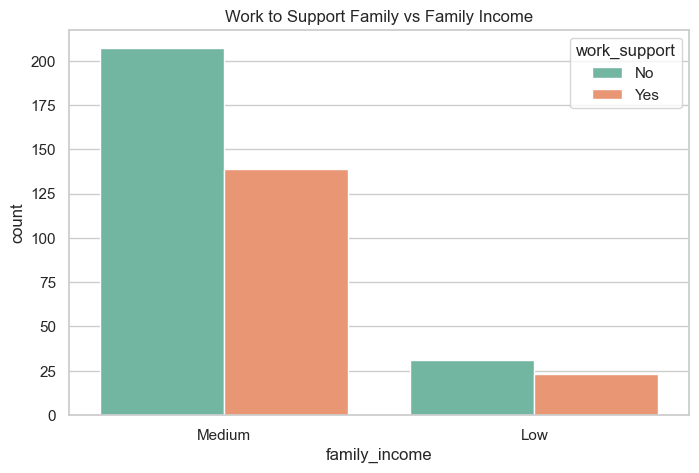

In [44]:
sns.countplot(
    data=df_cleaned,
    x="family_income",
    hue="work_support",
    palette="Set2"
)
plt.title("Work to Support Family vs Family Income")
plt.show()

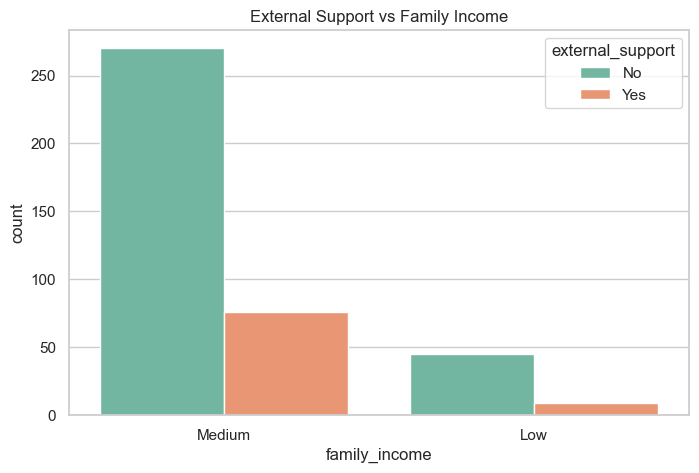

In [45]:
sns.countplot(
    data=df_cleaned,
    x='family_income',
    hue='external_support',
    order=df_cleaned['family_income'].value_counts().index,
    palette="Set2"
)

plt.title("External Support vs Family Income")
plt.show()

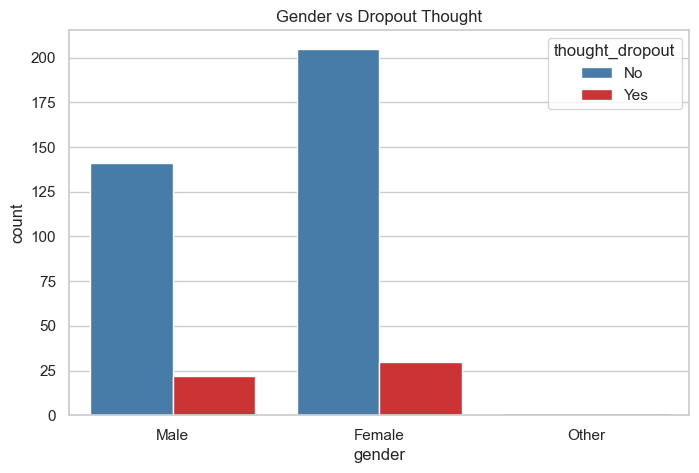

In [46]:
sns.countplot(
    data=df_cleaned,
    x='gender',
    hue='thought_dropout',
    palette=yes_no_palette
)

plt.title("Gender vs Dropout Thought")
plt.show()

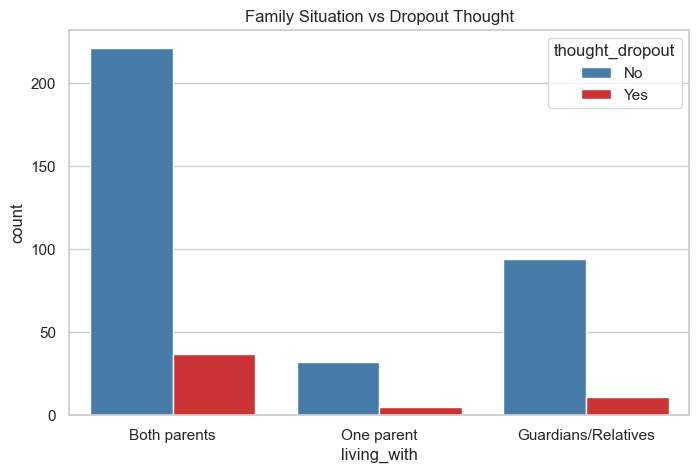

In [47]:
sns.countplot(
    data=df_cleaned,
    x='living_with',
    hue='thought_dropout',
    palette=yes_no_palette
)

plt.title("Family Situation vs Dropout Thought")
plt.show()

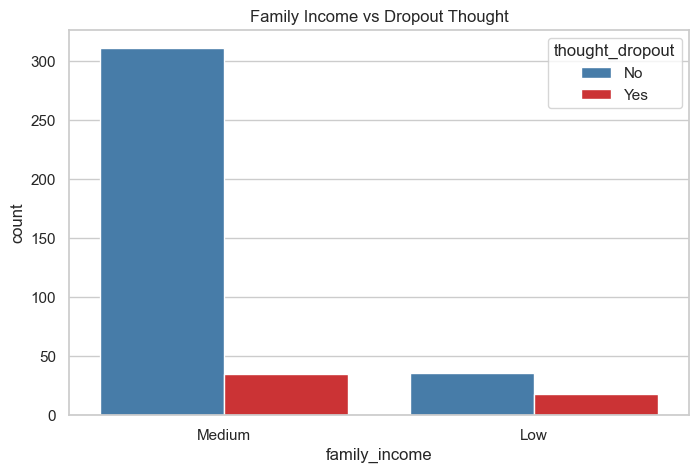

In [48]:
sns.countplot(
    data=df_cleaned,
    x='family_income',
    hue='thought_dropout',
    palette=yes_no_palette
)

plt.title("Family Income vs Dropout Thought")
plt.show()

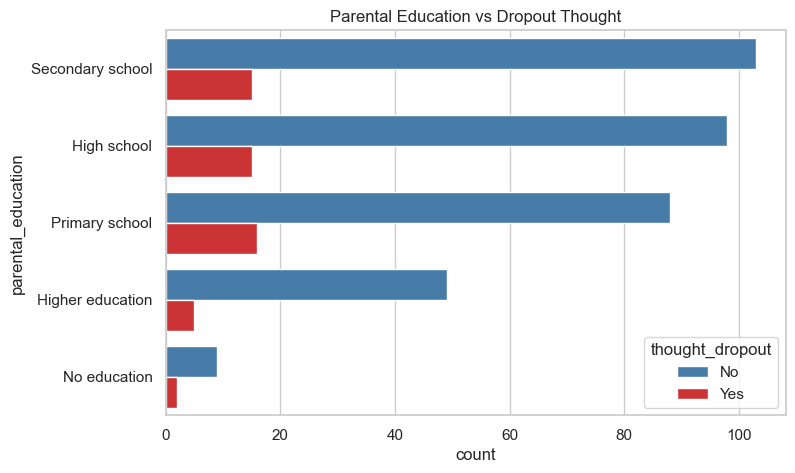

In [49]:
sns.countplot(
    data=df_cleaned,
    y='parental_education',
    hue='thought_dropout',
    order=df_cleaned['parental_education'].value_counts().index,
    palette=yes_no_palette
)

plt.title("Parental Education vs Dropout Thought")
plt.show()

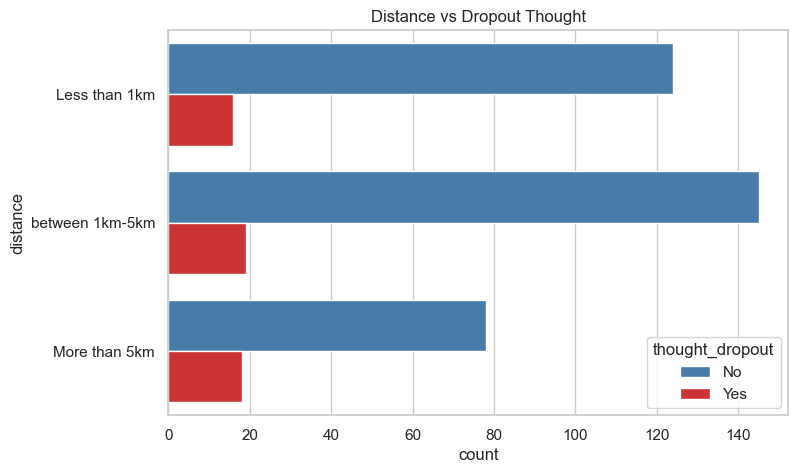

In [50]:
order = ['Less than 1km', 'between 1km-5km', 'More than 5km']

sns.countplot(
    data=df_cleaned,
    y='distance',
    hue='thought_dropout',
    order=order,
    palette=yes_no_palette
)

plt.title("Distance vs Dropout Thought")
plt.show()

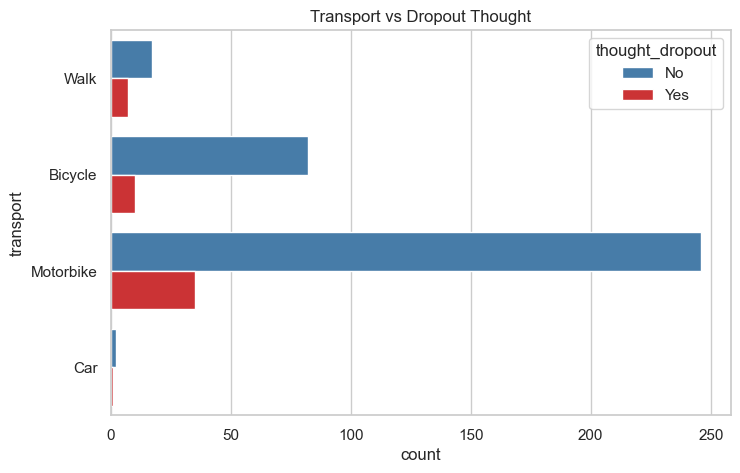

In [51]:
order = ['Walk', 'Bicycle', 'Motorbike', 'Car']

sns.countplot(
    data=df_cleaned,
    y='transport',
    hue='thought_dropout',
    order=order,
    palette=yes_no_palette
)

plt.title("Transport vs Dropout Thought")
plt.show()

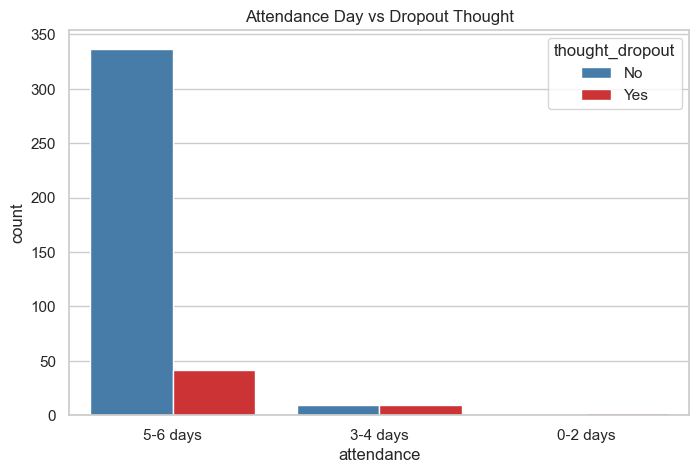

In [52]:
sns.countplot(
    data=df_cleaned,
    x='attendance',
    hue='thought_dropout',
    palette=yes_no_palette
)

plt.title("Attendance Day vs Dropout Thought")
plt.show()

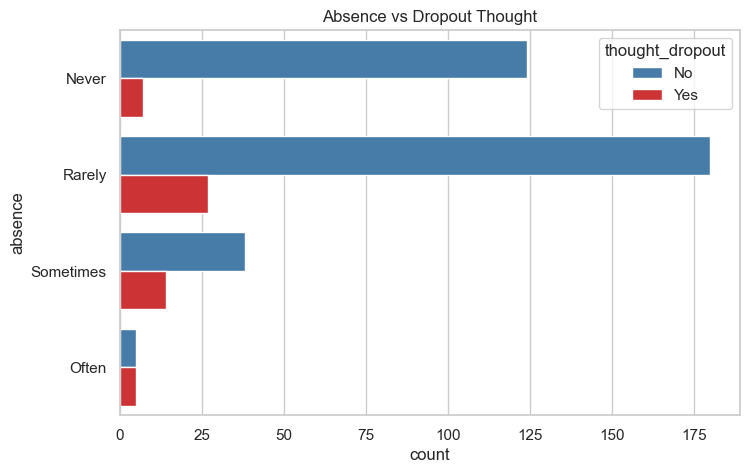

In [53]:
order = ["Never", "Rarely", "Sometimes", "Often"]  # Assuming absence values are 0 to 4

sns.countplot(
    data=df_cleaned,
    y='absence',
    hue='thought_dropout',
    order=order,
    palette=yes_no_palette
)

plt.title("Absence vs Dropout Thought")
plt.show()

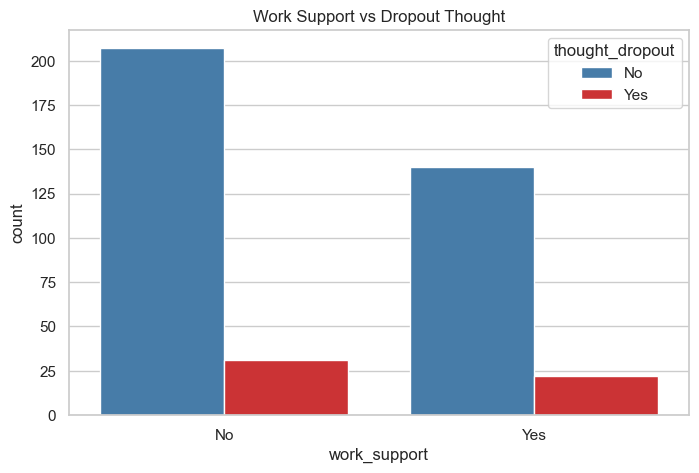

In [54]:
sns.countplot(
    data=df_cleaned,
    x='work_support',
    hue='thought_dropout',
    palette=yes_no_palette
)

plt.title("Work Support vs Dropout Thought")
plt.show()

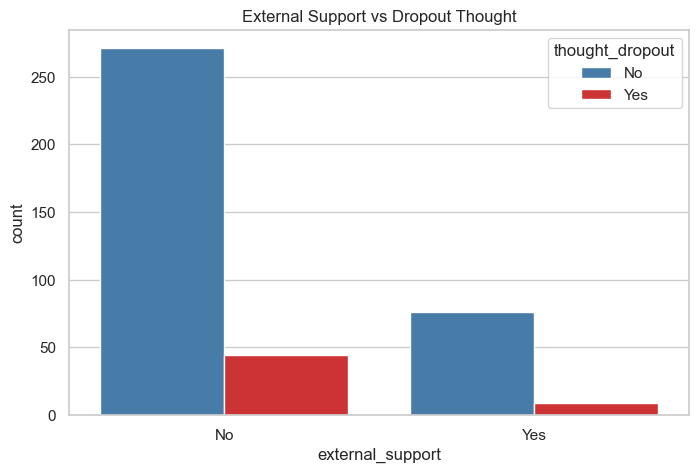

In [55]:
sns.countplot(
    data=df_cleaned,
    x='external_support',
    hue='thought_dropout',
    order=df_cleaned['external_support'].value_counts().index,
    palette=yes_no_palette
)

plt.title("External Support vs Dropout Thought")
plt.show()

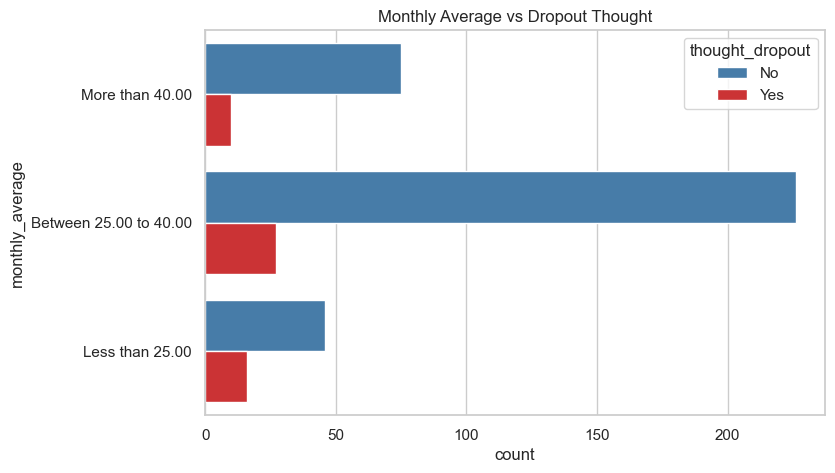

In [56]:
sns.countplot(
    data=df_cleaned,
    y='monthly_average',
    hue='thought_dropout',
    # order=df_cleaned['monthly_average'].value_counts().index,
    palette=yes_no_palette
)

plt.title("Monthly Average vs Dropout Thought")
plt.show()

In [57]:
df.columns

Index(['student_name', 'gender', 'age', 'province', 'study_level',
       'living_with', 'distance', 'transport', 'attendance', 'absence',
       'parental_education', 'family_income', 'work_support',
       'monthly_average', 'thought_dropout', 'external_support'],
      dtype='str')

## Feature Engineering

Feature engineering was performed to create more meaningful indicators related to:

- student engagement
- attendance quality
- socioeconomic conditions
- educational support
- dropout vulnerability

These engineered features help uncover deeper patterns beyond the original survey variables.

### Encoding

In [58]:
df_cleaned.head()

,gender,living_with,distance,transport,attendance,absence,parental_education,family_income,work_support,monthly_average,external_support,thought_dropout
0,Male,Both parents,Less than 1km,Motorbike,5-6 days,Never,High school,Medium,No,More than 40.00,No,No
1,Female,Both parents,between 1km-5km,Motorbike,5-6 days,Never,High school,Medium,No,Between 25.00 to 40.00,No,No
2,Male,Both parents,between 1km-5km,Motorbike,5-6 days,Sometimes,High school,Medium,No,Between 25.00 to 40.00,No,Yes
3,Male,Both parents,between 1km-5km,Motorbike,5-6 days,Never,Primary school,Medium,No,Between 25.00 to 40.00,No,No
4,Female,Both parents,Less than 1km,Motorbike,5-6 days,Never,Primary school,Medium,No,More than 40.00,No,No


In [59]:
for col in df_cleaned.columns:
    print(f"Unique values in '{col}': {df_cleaned[col].unique()}\n")

Unique values in 'gender': <ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

Unique values in 'living_with': <ArrowStringArray>
['Both parents', 'One parent', 'Guardians/Relatives']
Length: 3, dtype: str

Unique values in 'distance': <ArrowStringArray>
['Less than 1km', 'between 1km-5km', 'More than 5km']
Length: 3, dtype: str

Unique values in 'transport': <ArrowStringArray>
['Motorbike', 'Bicycle', 'Walk', 'Car']
Length: 4, dtype: str

Unique values in 'attendance': <ArrowStringArray>
['5-6 days', '3-4 days', '0-2 days']
Length: 3, dtype: str

Unique values in 'absence': <ArrowStringArray>
['Never', 'Sometimes', 'Rarely', 'Often']
Length: 4, dtype: str

Unique values in 'parental_education': <ArrowStringArray>
[     'High school',   'Primary school', 'Secondary school',
     'No education', 'Higher education']
Length: 5, dtype: str

Unique values in 'family_income': <ArrowStringArray>
['Medium', 'Low']
Length: 2, dtype: str

Unique values in 'work_support': <Arrow

In [60]:
encoded_df = df_cleaned.copy()

In [61]:
gen_map = {
    'Male': 0,
    'Female': 1,
    'Other': 2
}
encoded_df['gender'] = encoded_df['gender'].map(gen_map)

In [62]:
living_map = {
    'Both parents': 2,
    'One parent': 1,
    'Guardians/Relatives': 0
}

encoded_df['living_with'] = encoded_df['living_with'].map(living_map)

In [63]:
distance_map = {
    'Less than 1km': 1,
    'between 1km-5km': 2,
    'More than 5km': 3
}

encoded_df['distance'] = encoded_df['distance'].map(distance_map)

In [64]:
transport_map = {
    "Walk": 3,
    "Bicycle": 2,
    "Motorbike": 1,
    "Car": 0
}
encoded_df['transport'] = encoded_df['transport'].map(transport_map)


In [65]:
attendance_map = {
    '5-6 days': 5,
    '3-4 days': 3,
    '0-2 days': 0
}
encoded_df['attendance'] = encoded_df['attendance'].map(attendance_map)

In [66]:
absence_map = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3
}
encoded_df['absence'] = encoded_df['absence'].map(absence_map)

In [67]:
parental_education_map = {
    'No education': 0,
    'Primary school': 1,
    'Secondary school': 2,
    'High school': 3,
    'Higher education': 4
}
encoded_df['parental_education'] = encoded_df['parental_education'].map(parental_education_map)

In [68]:
family_income_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}
encoded_df['family_income'] = encoded_df['family_income'].map(family_income_map)

In [69]:
work_support_map = {
    'Yes': 1,
    'No': 0
}
encoded_df['work_support'] = encoded_df['work_support'].map(work_support_map)

In [70]:
monthly_average_map = {
    'Less than 25.00': 0,
    'Between 25.00 to 40.00': 1,
    'More than 40.00': 2,
}
encoded_df['monthly_average'] = encoded_df['monthly_average'].map(monthly_average_map)

In [71]:
external_support_map = {
    'Yes': 1,
    'No': 0
} 
encoded_df['external_support'] = encoded_df['external_support'].map(external_support_map)

In [72]:
thought_dropout_map = {
    'Yes': 1,
    'No': 0
}
encoded_df['thought_dropout'] = encoded_df['thought_dropout'].map(thought_dropout_map)

In [73]:
encoded_df.head()

,gender,living_with,distance,transport,attendance,absence,parental_education,family_income,work_support,monthly_average,external_support,thought_dropout
0,0,2,1,1,5,0,3,1,0,2,0,0
1,1,2,2,1,5,0,3,1,0,1,0,0
2,0,2,2,1,5,2,3,1,0,1,0,1
3,0,2,2,1,5,0,1,1,0,1,0,0
4,1,2,1,1,5,0,1,1,0,2,0,0


### Correlation Analysis

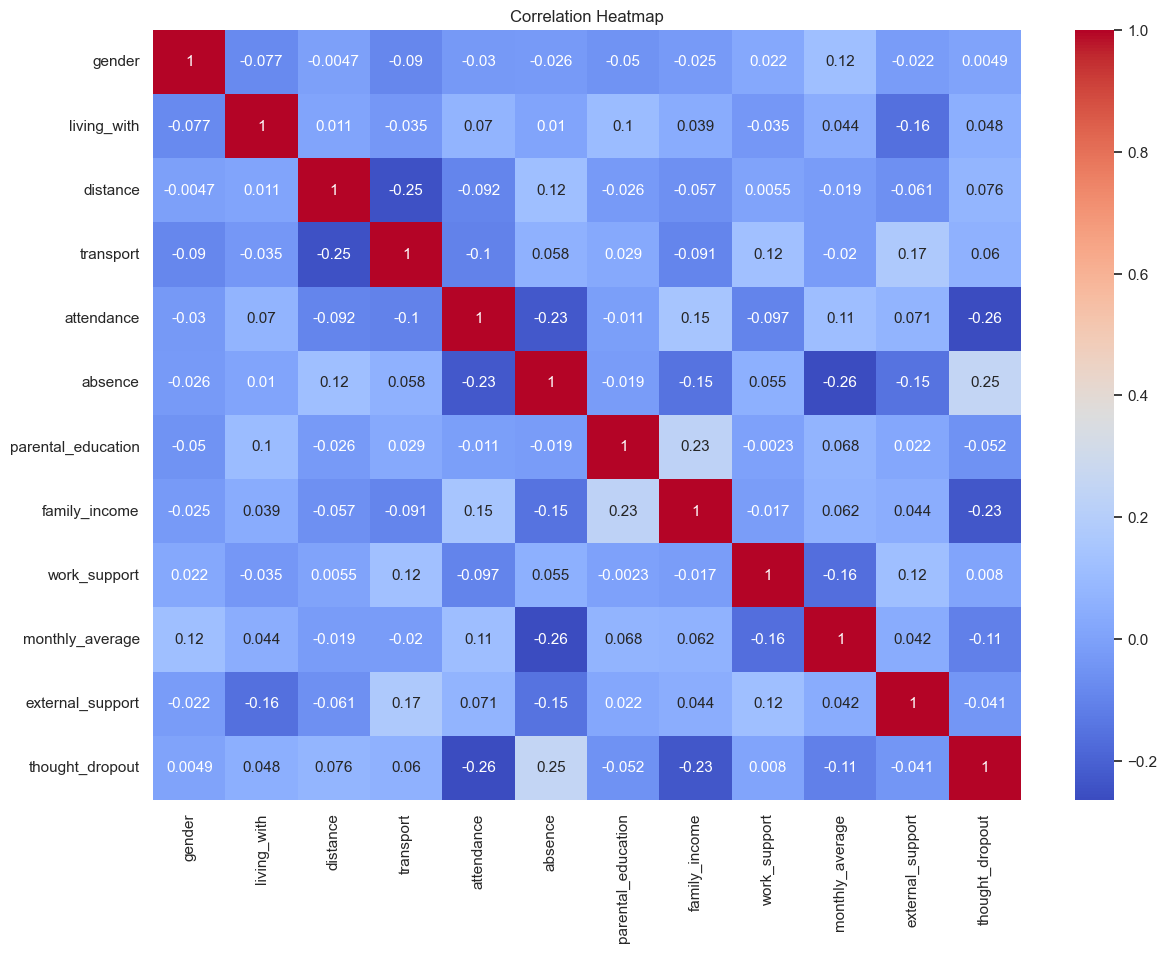

In [74]:
corr = encoded_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

``Correlation analysis was performed on encoded categorical variables for exploratory purposes only. Interpretations should be treated cautiously because categorical encodings do not represent true numerical distances.``

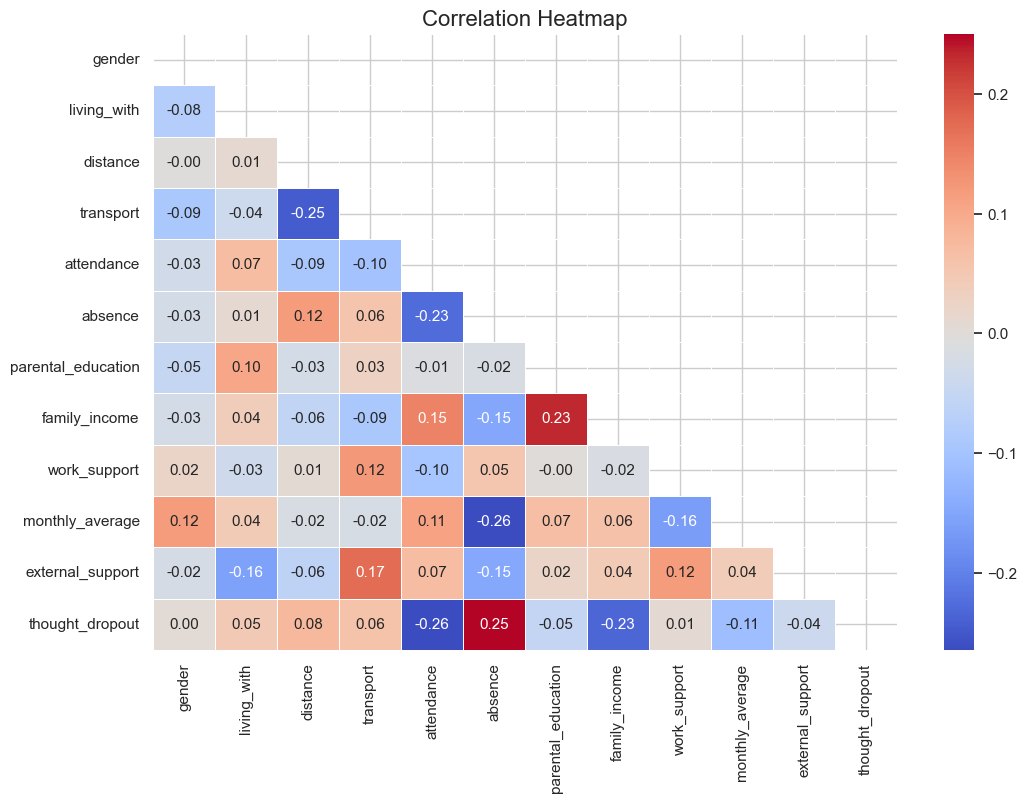

In [75]:
plt.figure(figsize=(12,8))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    mask=mask
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

### Cramer's V

In [76]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    contingency_table = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [77]:
categorical_cols = [

    'gender',
    'living_with',
    'distance',
    'transport',
    'attendance',
    'absence',
    'parental_education',
    'family_income',
    'work_support',
    'external_support',
    'thought_dropout'
    
]

In [78]:
cramers_v_matrix = pd.DataFrame(
    np.zeros(
        (len(categorical_cols), 
         len(categorical_cols))
    ),
    index=categorical_cols, 
    columns=categorical_cols
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            v = cramers_v(encoded_df[col1], encoded_df[col2])
            cramers_v_matrix.loc[col1, col2] = v
            cramers_v_matrix.loc[col2, col1] = v

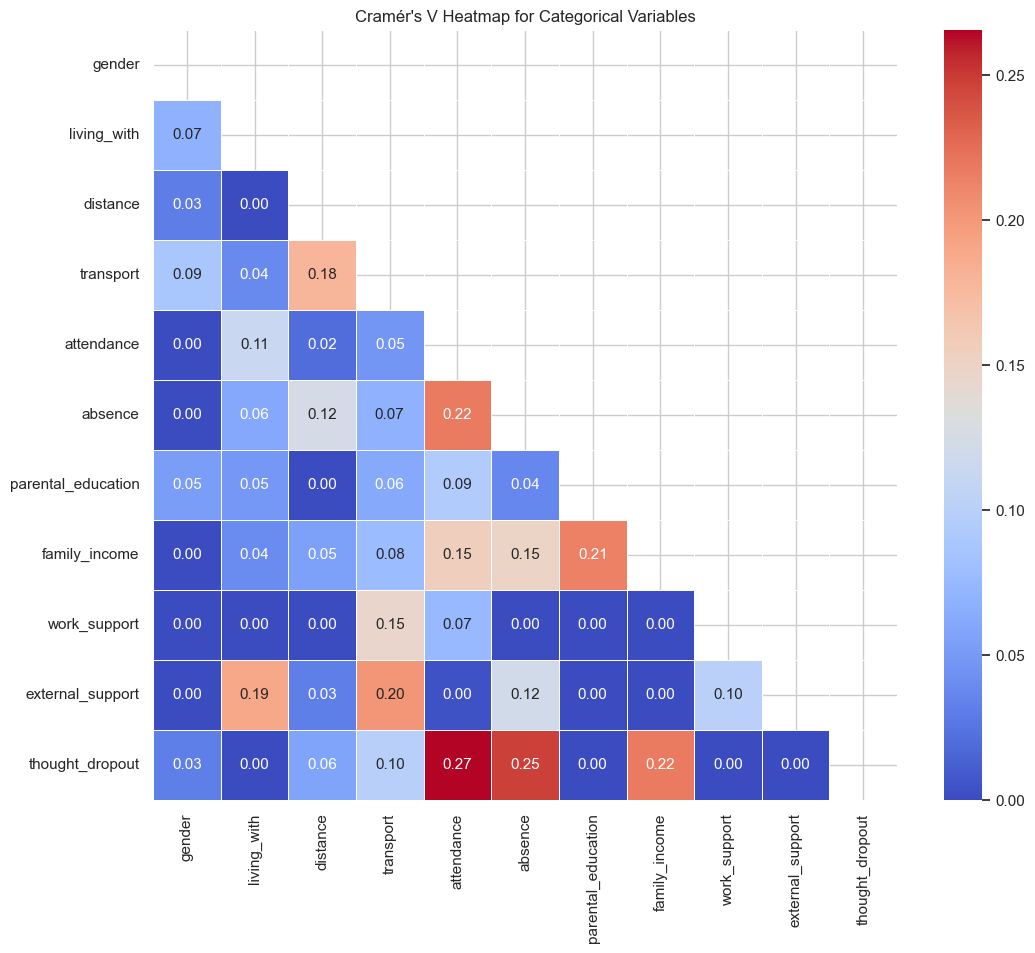

In [79]:
mask = np.triu(np.ones_like(cramers_v_matrix, dtype=bool))

plt.figure(figsize=(12,10))
sns.heatmap(
    cramers_v_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    mask=mask
)
plt.title("Cramér's V Heatmap for Categorical Variables")
plt.show()

The Cramér’s V heatmap above is showing which categorical variables are associated with each other and with thought_dropout.

Now we can engineer features based on meaningful relationships instead of random combinations.

From the heatmap, the strongest associations with thought_dropout are:

Feature	Cramér’s V
- attendance	0.27
- absence	0.25
- family_income	0.22
- transport	0.10
- distance	0.06
- gender 0.03

So the feature engineering should focus on:

- attendance behavior
- academic engagement
- socioeconomic condition
- transportation burden
- support environment

In [80]:
raw_features = [
    'gender',
    'transport',
    'attendance',
    'absence',
    'family_income',

    'monthly_average',
    'parental_education',
    'external_support',
    'living_with',
    'distance',
    'work_support'
]

### Engineer features

In [81]:
encoded_df['attendance_quality'] = (
    encoded_df['attendance']
    - encoded_df['absence']
)

encoded_df['engagement_score'] = (
    encoded_df['attendance']
    + encoded_df['monthly_average']
    - encoded_df['absence']
)

encoded_df['ses_score'] = (
    encoded_df['family_income']
    + encoded_df['parental_education']
    + encoded_df['external_support']
)

encoded_df['support_index'] = (
    encoded_df['living_with']
    + encoded_df['parental_education']
    + encoded_df['external_support']
)

encoded_df['commute_burden'] = (
    encoded_df['distance']
    + encoded_df['transport']
)

encoded_df['financial_pressure'] = (
    encoded_df['work_support']
    - encoded_df['family_income']
)

encoded_df['academic_risk'] = (
    encoded_df['absence']
    - encoded_df['monthly_average']
)

# Calculate risk score and weighted risk score for clustering
encoded_df['risk_score'] = (
    encoded_df['absence']
    + encoded_df['work_support']
    + encoded_df['distance']
    + encoded_df['thought_dropout']
)

encoded_df['weighted_risk_score'] = (
    0.3 * encoded_df['absence']
    + 0.1 * encoded_df['work_support']
    + 0.2 * encoded_df['distance']
    + 0.4 * encoded_df['thought_dropout']
)

encoded_df['normalized_risk_score'] = (
    (1/3) * encoded_df['absence']
    + 1.0 * encoded_df['work_support']
    + 0.5 * encoded_df['distance']
    + 1.0 * encoded_df['thought_dropout']
)

encoded_df['high_risk_student'] = (
    encoded_df['weighted_risk_score'] > 0.85
).astype(int)

def calculate_risk_group(row):
    wrs = row['weighted_risk_score']
    td = row['thought_dropout']
    ws = row['work_support']
    nrs = row['normalized_risk_score']
    if wrs <= 0.65:
        if td <= 0.5:
            return 'Low'
        else:
            if ws <= 0.5:
                return 'Medium'
            else:
                return 'Low'
    else:
        if wrs <= 1.25:
            if nrs <= 3.08:
                return 'Medium'
            else:
                return 'High'
        else:
            return 'High'

encoded_df['risk_group'] = encoded_df.apply(calculate_risk_group, axis=1)


In [82]:
engineered_features = [
    'attendance_quality',
    'engagement_score',
    'ses_score',
    'support_index',
    'commute_burden',
]

In [83]:
selected_features = [
    'gender',
    'transport',
    # 'attendance',
    # 'absence',
    'family_income',
] + engineered_features

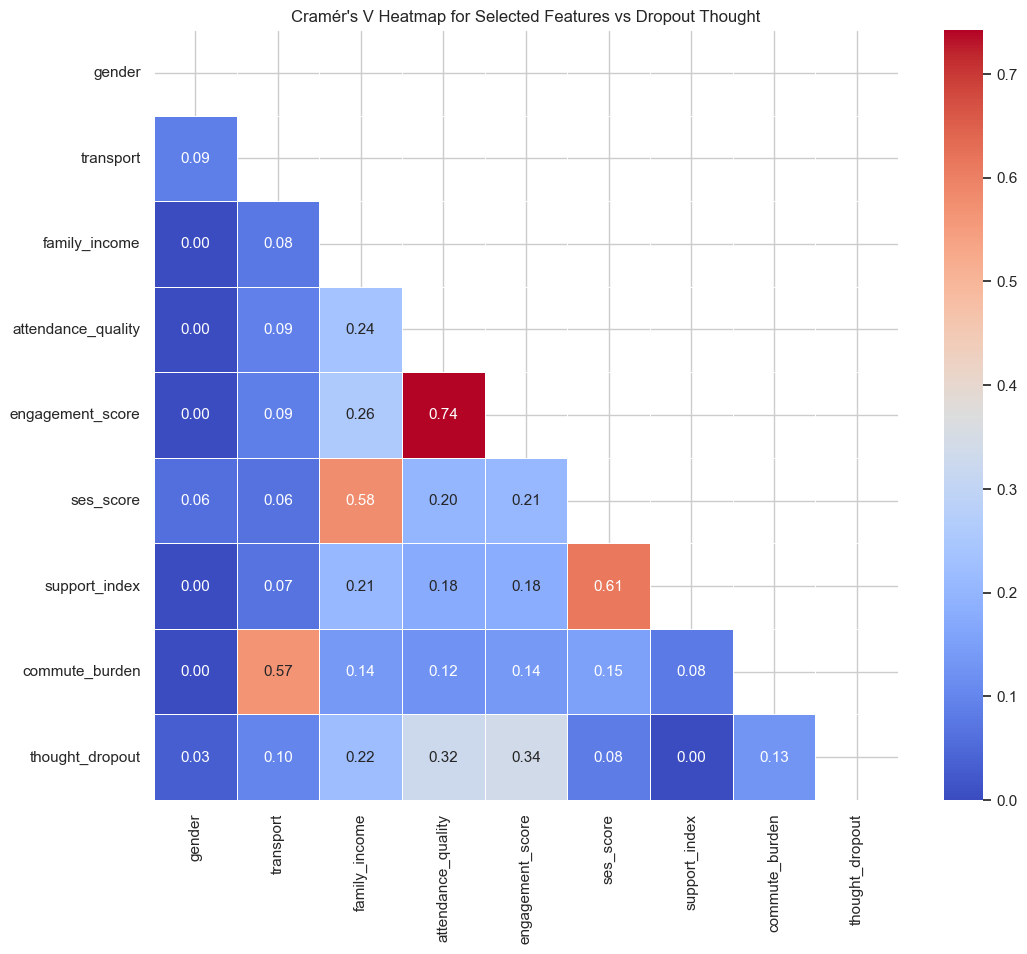

In [84]:
cramers_v_matrix = pd.DataFrame(
    np.zeros(
        (len(selected_features + ['thought_dropout']), 
         len(selected_features + ['thought_dropout']))
    ),
    index=selected_features + ['thought_dropout'], 
    columns=selected_features + ['thought_dropout']
)
for col1 in selected_features + ['thought_dropout']:
    for col2 in selected_features + ['thought_dropout']:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            v = cramers_v(encoded_df[col1], encoded_df[col2])
            cramers_v_matrix.loc[col1, col2] = v
            cramers_v_matrix.loc[col2, col1] = v
            
mask = np.triu(np.ones_like(cramers_v_matrix, dtype=bool))

plt.figure(figsize=(12,10))
sns.heatmap(
    cramers_v_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    mask=mask
)
plt.title("Cramér's V Heatmap for Selected Features vs Dropout Thought")
plt.show()


### References

1. Balfanz, R., Herzog, L., & Mac Iver, D. J. (2007).  
Preventing Student Disengagement and Keeping Students on the Graduation Path in Urban Middle-Grades Schools.  
Educational Psychologist, 42(4), 223–235.

2. Romero, C., & Ventura, S. (2010).  
Educational Data Mining: A Review of the State of the Art.  
IEEE Transactions on Systems, Man, and Cybernetics, 40(6), 601–618.

3. Fredricks, J. A., Blumenfeld, P. C., & Paris, A. H. (2004).  
School Engagement: Potential of the Concept, State of the Evidence.  
Review of Educational Research, 74(1), 59–109.

4. Sirin, S. R. (2005).  
Socioeconomic Status and Academic Achievement: A Meta-Analytic Review of Research.  
Review of Educational Research, 75(3), 417–453.

5. Dekker, G. W., Pechenizkiy, M., & Vleeshouwers, J. M. (2009).  
Predicting Students Drop Out: A Case Study.  
International Working Group on Educational Data Mining.

In [85]:
encoded_df.to_csv('../data/student_dropout_processed.csv', index=False)